In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

sns.set_theme(style="darkgrid") 
np.random.seed(42)

______
# Probability using python /pandas 

## Creating a sample space

In [2]:
# Create a df with 10 random integers out of 20
values = np.random.randint(1,101,5)
sample_space = pd.DataFrame(values, columns=["values"])
print("Sample space:")
print(f"{sample_space}\n")
# Pick any 2 values out of these :
ss=sample_space.sample(n=2)
print(f"Selected values: {ss}")

Sample space:
   values
0      52
1      93
2      15
3      72
4      61

Selected values:    values
3      72
0      52


In [3]:
# Sample space for a dice roll
dice = pd.DataFrame(data=np.arange(1,7),columns=["vals"])
dice

,vals
0,1
1,2
2,3
3,4
4,5
5,6


## Sampling from a dataframe
Picking n random samples from a sample space with/eithout replacement. The `replace` parameter is used to control this behaviour. 

`replace=True` is Sampling with replacement means the current sampled value is returned back into the sample space before taking the next sample.<br>
It could happen that same value is picked twice in such case. This ensures that each sample in this case is an independent event - outcome of one event is independent of the outcome of another event.

`replace=False(default)` on the other hand, is sampling without replacement meaning 2nd sample is a dependent event - its sample space changes after the first event.

In [ ]:
# Rolling the dice twice & getting any two random numbers
dice.sample(n=2)

,vals
1,2
4,5


In [ ]:
dice.sample(n=2, replace=True)

,vals
2,3
2,3


# Probabilty distributions
The probability of each possible outcome in a scenario

In [28]:
# Simulate 10 dice rolls  (taking 10 samples)
dice.sample(n=10, replace=True)

,vals
3,4
5,6
2,3
2,3
3,4
3,4
5,6
1,2
5,6
1,2


## 1. Discrete distributions
A fair die rolled for n number of times - probability is equal for each no. to show up.

### The Law Of Large Numbers
As sample size increases, the sample mean will approach the expected value.

In [68]:
np.mean(dice["vals"])

np.float64(3.5)

In [54]:
# Rolled for 10 times
rolls10x = dice.sample(n=10, replace=True)
meanrolls10x = rolls10x.mean()

rolls100x = dice.sample(n=100, replace=True)
meanrolls100x = rolls100x.mean()

rolls1000x = dice.sample(n=1000, replace=True)
meanrolls1000x = rolls1000x.mean()

rolls10Kx = dice.sample(n=10000, replace=True)
meanrolls10Kx = rolls10Kx.mean()

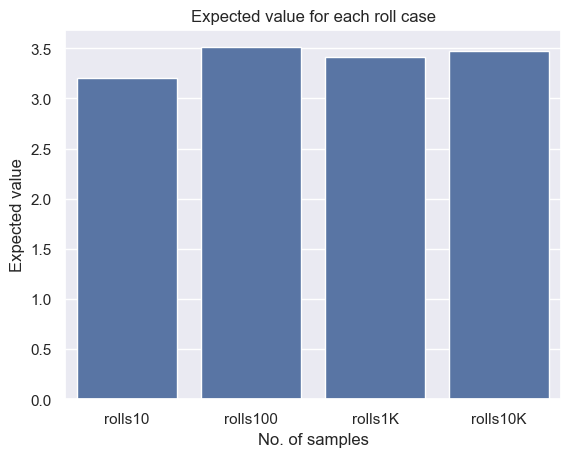

In [63]:
scenarios = [meanrolls10x, meanrolls100x, meanrolls1000x, meanrolls10Kx]
titles = ["rolls10","rolls100", "rolls1K", "rolls10K"]

sample_mean_p = pd.DataFrame(scenarios, index=titles)
sample_mean_p

sns.barplot(data= sample_mean_p, x= sample_mean_p.index , y="vals")
plt.title("Expected value for each roll case")
plt.xlabel("No. of samples")
plt.ylabel("Expected value")
plt.show()

### 1.A Binomial Distribution
A binomial distribution is a discrete probability distribution that models the count of successes in a set number of binomial trials (Bernoulli's trials). Each trial in this scenario has only two possible outcomes, often labeled as "success" and "failure," with a consistent probability of success across all trials.

What is a Bernoulli trial?
- A single experiment that has exactly 2 possible outcomes
- Outcome in one trail is independent of outcome of previous trials

### `binom` module of  `scipy.stats`

Used for binomial distributions, models probability of _k_ successes in _n_ Bernoulli's trials.

> Helps answer How many success in n trials?

`binom.rvs` is used to simulate a random experiment that follows a Binomial Distribution. Its basically a 'virtual coin flipper'. tells you how many "successes" occur in a set number of trials, given a specific probability of success.

Example: we'll model a coin flip -- both the head as well as tail has 50% chance. Assume H as success (win) and T as failure(loss)

In [89]:
from scipy.stats import binom

# Flipping 1 coin with 50% chance of success for 10 times
binom.rvs(n=1,p=0.5,size=10)

array([0, 1, 1, 1, 0, 0, 1, 0, 1, 1])

In [102]:
# Flipping 8 coins with 50% chance of success for 1 time -- gives total  no. of Hs obtained in one trial
binom.rvs(n=8,p=0.5,size=1)

array([4])

In [97]:
# Flipping two coins once with 50% chance of H -- gives no. of successes
binom.rvs(n=2,p=0.5,size=1)

array([1])

In [99]:
# Flipping 3 coins for 10 times with 50% chance of H -- gives no. of successes for each trial
binom.rvs(n=3,p=0.5,size=10)

array([1, 2, 2, 2, 2, 2, 1, 1, 3, 2])

In [ ]:
# For a coin thats heavier on one side than other (only 25% chance of H)
binom.rvs(n=3, p=0.25, size=10)
# We observe the no. of successes has decreased significantly 

array([1, 0, 1, 1, 0, 1, 1, 3, 1, 1])

### Probability Mass Functions (for point probability)
Used for discrete probability, gives the probability of an exact value (e.g., "What is the chance of exactly _`k`_ successes in _`n`_ trials? given _`p`_ probability").

it answers the question: _"If I flip a fair coin (p=0.5) ten times (n=10), what is the exact chance I will get exactly five heads (k=5)?"_

In [106]:
# P(X = 5)
binom.pmf(k=5, n=10, p=0.5)

np.float64(0.24609375)

IF we flip a fair coin 10 times, there's a ~25% chance that 5 of these trials are H

### Cumulative Distributive Function (CDF)
Used for both continuous as well as discrete distributions. 

Answers _"What is the probability that the result is $X$ or less?"_

Answers the question: _If I flip a fair coin (p=0.5) ten times (k=10) , what is the probability I will get at most 5 heads (k=5) ?_

In [70]:
# P(X <= 5)
binom.cdf(k=5, n=10, p=0.5)

np.float64(0.623046875)

Below code answers the question: _If I flip a fair coin (p=0.5) ten times (k=10) , what is the probability I will more than 5 heads (k=5) ?_

In [107]:
# P(X > 5)
1 - binom.cdf(k=5, n=10, p=0.5)

np.float64(0.376953125)

___
## 2. Continuous distribution
### Normal distribution
### Using `norm` module of the `sipy.stats` library

In [117]:
sampledf = pd.read_csv('./stats_datasets/weightsheights.csv', usecols=["Height in cm"	,"Weight in kg"])
sampledf.head()

,Height in cm,Weight in kg
0,167.089517,51.252597
1,181.648535,61.909672
2,176.272704,69.411917
3,173.270070,64.562328
4,172.180944,65.452141


In [166]:
stats = sampledf.describe()
print(f"{stats}\n")
print(f"Population size is {stats.loc["count","Height in cm"]}")
height_mean = round(float(stats.loc["mean","Height in cm"]),2)
height_stdev =  round(float(stats.loc["mean","Height in cm"]),2)


       Height in cm  Weight in kg
count  25000.000000  25000.000000
mean     172.702415     57.642324
std        4.830261      5.289300
min      153.106952     35.386942
25%      169.429078     54.117569
50%      172.708985     57.677854
75%      175.953217     61.186440
max      190.888009     77.529914

Population size is 25000.0


<Axes: >

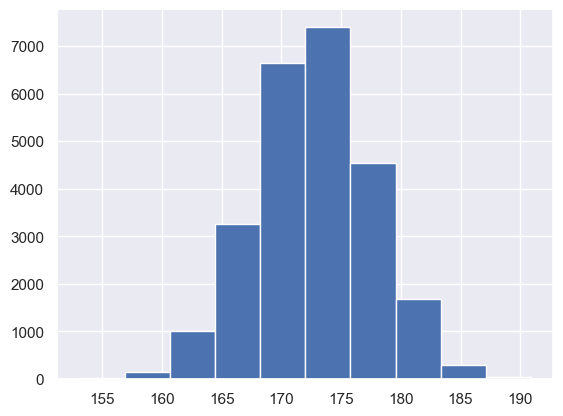

In [119]:
# Taking sample distribution of heights
sampledf["Height in cm"].hist()

The height distribution somewhat resembles a normal distribution (Bell curve). So , we can apply probabilistic methods for the normal distribution.

In [120]:
# importing the norm module
from scipy.stats import norm

Finding stats on the Population height

What % of population is having height less than 165cm?

In [178]:
norm.cdf(165, height_mean, height_stdev )

np.float64(0.4822186560491894)

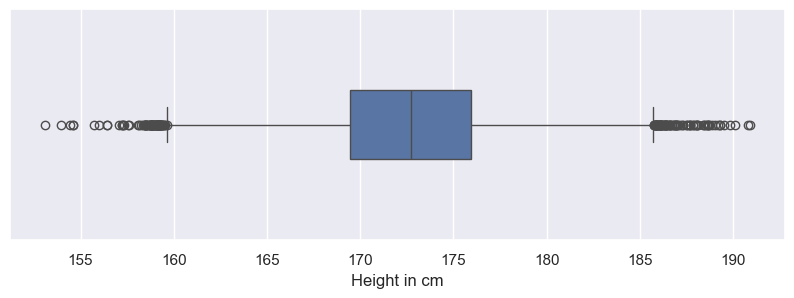

In [184]:
plt.subplots(figsize=(10,3))
sns.boxplot(data=sampledf, x="Height in cm", width=0.3)
plt.show()

### Proving the Central Limit Theorem
If sampling size of a population is large enough (n>=30), sampling distribution of means of all samples (100 in below case) will represent normal distribution. This is regardless of the population's data distribution 

In [159]:
sample_mean_value = []
for n in range(1000):
    val = sampledf["Height in cm"].sample(n=30).mean()
    sample_mean_value.append(val)
print(sample_mean_value)

[np.float64(174.0794460766667), np.float64(172.6102516), np.float64(172.13803791666663), np.float64(173.44926056), np.float64(171.76006496), np.float64(172.8446376), np.float64(171.83923502000002), np.float64(174.35313855333328), np.float64(171.5335131566667), np.float64(172.8618316866667), np.float64(173.03181517666673), np.float64(173.36948089999996), np.float64(171.9145874666667), np.float64(172.25463993999998), np.float64(172.9625858233333), np.float64(172.4808733866667), np.float64(171.56623257666666), np.float64(172.66564812333334), np.float64(171.17761532666663), np.float64(171.64678356), np.float64(172.41477162333334), np.float64(172.73437117333333), np.float64(172.49701338000003), np.float64(172.81818689), np.float64(172.7967450766666), np.float64(173.18157519333334), np.float64(171.9178708466666), np.float64(173.19495844333335), np.float64(174.45795158666664), np.float64(172.03859866999997), np.float64(173.48558085666667), np.float64(172.18686346), np.float64(172.761807396666

In [160]:
df_allSampleMeans = pd.DataFrame(data=sample_mean_value, columns=["each_sample_mean"])

<Axes: xlabel='each_sample_mean', ylabel='Count'>

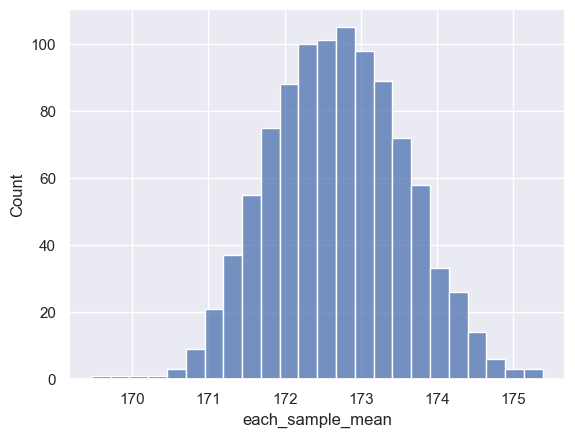

In [161]:
sns.histplot(data=df_allSampleMeans, x=df_allSampleMeans["each_sample_mean"])

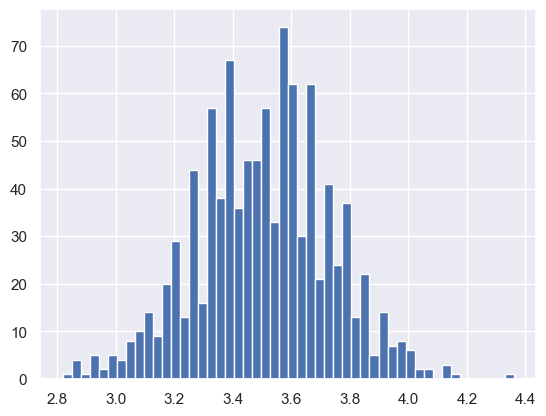

In [87]:
means = []

for _ in range(1000):
    sample = np.random.randint(1, 7, size=50)
    means.append(sample.mean())

plt.hist(means, bins=50)
plt.show()

______
# Probability Examples 

In [5]:
employees = pd.read_csv("./stats_datasets/company_employee_details.csv",index_col=0)
employees.head()

,company,department,employee_id,age,age_when_joined,years_in_the_company,salary,annual_bonus,prior_years_experience,full_time,part_time,contractor
0,Glasses,BigData,16,41,38,3,68074.971354,17664.104103,3,0.000000,0.000000,1.000000
1,Glasses,AI,56,44,42,2,49092.147458,21551.141079,2,0.000000,0.184991,1.000000
2,Cheerper,Support,59,41,40,1,40000.000000,23698.878851,2,0.000000,0.919887,0.662706
3,Glasses,Design,40,39,32,7,108192.465506,21570.929657,1,0.930396,0.546206,0.000000
4,Glasses,Search Engine,47,30,22,9,71291.191132,21565.505715,2,0.525432,0.938412,0.000000


In [6]:
employees[employees["employee_id"]==1].sort_values(["age_when_joined"])

,company,department,employee_id,age,age_when_joined,years_in_the_company,salary,annual_bonus,prior_years_experience,full_time,part_time,contractor
4983,Glasses,Design,1,31,22,9,153000.000000,20047.354967,1,0.904638,0.319385,0.000000
123,Pear,Design,1,31,22,8,125567.106713,21018.212875,2,0.993432,0.000000,0.161885
128,Glasses,Search Engine,1,30,22,9,90279.288950,12051.836178,4,0.647487,0.473869,0.000000
142,Glasses,Search Engine,1,30,22,6,95776.399657,24792.910000,1,0.241206,0.161386,0.597241
147,Pear,Sales,1,30,22,9,141689.027417,24792.910000,1,0.949353,0.199435,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
1440,Pear,Sales,1,48,47,1,153000.000000,18524.104771,2,0.974532,0.000000,0.638013
3241,Glasses,AI,1,49,47,4,123273.543895,14280.859865,2,0.216794,0.154969,0.628370
2008,Glasses,Search Engine,1,49,48,1,125752.695554,21633.115096,1,0.000000,0.213112,0.932454
4573,Pear,Sales,1,49,48,1,153000.000000,15029.228673,2,1.000000,0.000000,0.524578


In [7]:
employees.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   company                 5000 non-null   object 
 1   department              5000 non-null   object 
 2   employee_id             5000 non-null   int64  
 3   age                     5000 non-null   int64  
 4   age_when_joined         5000 non-null   int64  
 5   years_in_the_company    5000 non-null   int64  
 6   salary                  5000 non-null   float64
 7   annual_bonus            5000 non-null   float64
 8   prior_years_experience  5000 non-null   int64  
 9   full_time               5000 non-null   float64
 10  part_time               5000 non-null   float64
 11  contractor              5000 non-null   float64
dtypes: float64(5), int64(5), object(2)
memory usage: 507.8+ KB


Rounding up the decimals

Iterating all columns with float dtype into a `for` loop to convert at once:

In [8]:
for column in employees.columns:
    if (employees[column].dtype=="float64"):
        employees[column]=employees[column].round(2)
    else:
        pass

In [9]:
employees.dtypes

company                    object
department                 object
employee_id                 int64
age                         int64
age_when_joined             int64
years_in_the_company        int64
salary                    float64
annual_bonus              float64
prior_years_experience      int64
full_time                 float64
part_time                 float64
contractor                float64
dtype: object

In [10]:
employees.head()

,company,department,employee_id,age,age_when_joined,years_in_the_company,salary,annual_bonus,prior_years_experience,full_time,part_time,contractor
0,Glasses,BigData,16,41,38,3,68074.97,17664.10,3,0.00,0.00,1.00
1,Glasses,AI,56,44,42,2,49092.15,21551.14,2,0.00,0.18,1.00
2,Cheerper,Support,59,41,40,1,40000.00,23698.88,2,0.00,0.92,0.66
3,Glasses,Design,40,39,32,7,108192.47,21570.93,1,0.93,0.55,0.00
4,Glasses,Search Engine,47,30,22,9,71291.19,21565.51,2,0.53,0.94,0.00


### Studying distribution of salaries by Department

In [11]:
tableau_10 = [
    "#4E79A7",  # Blue
    "#F28E2B",  # Orange
    "#E15759",  # Red
    "#76B7B2",  # Teal
    "#59A14F",  # Green
    "#EDC948",  # Yellow
    "#B07AA1",  # Purple
    "#FF9DA7",  # Pink
    "#9C755F",  # Brown
    "#BAB0AC",  # Gray
]

Need to show separate distribution by department for better understnding

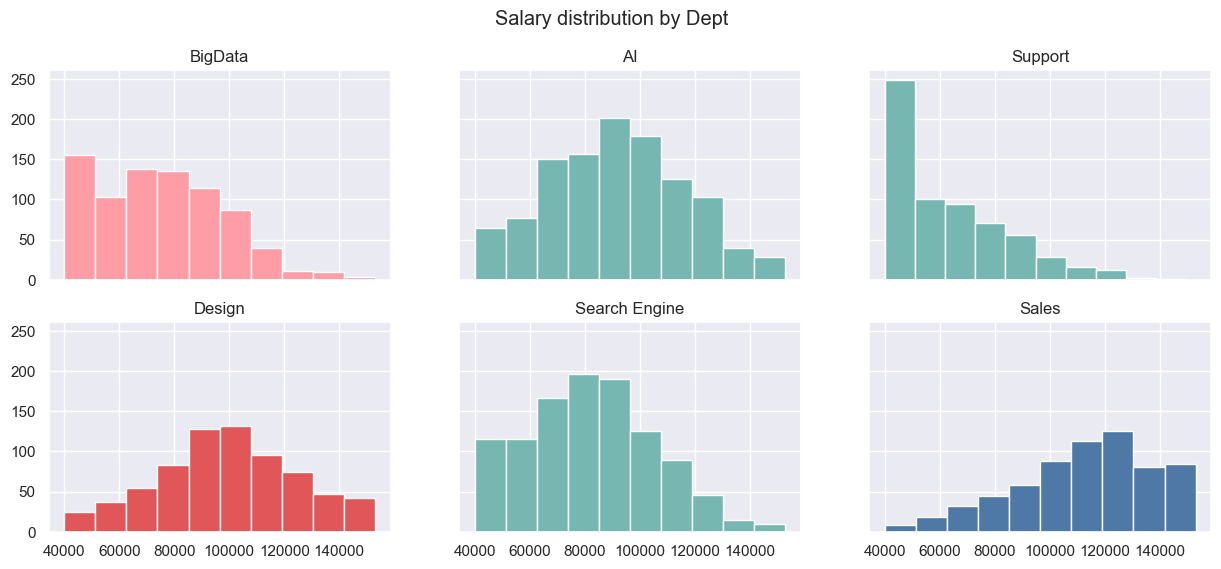

In [12]:
fig,ax = plt.subplots(2,3,sharey=True,sharex=True,figsize=(15,6))

# Creating list of departments
dept_list = list(employees["department"].unique())

for i,dept in enumerate(dept_list):
    # For Row#0
    if i<3:
        ax[0,i].hist(data=employees[employees["department"]==dept], x="salary",color=random.choice(tableau_10))
        ax[0,i].set_title(dept)
    # For Row#1
    elif i>=3: 
        #Note that column no. has to to be reset - i.e start from 0 again for Row1
        ax[1,i-3].hist(data=employees[employees["department"]==dept], x="salary",color=random.choice(tableau_10))
        ax[1,i-3].set_title(dept)

plt.suptitle("Salary distribution by Dept")
plt.show()

### Observations:
Salaries for Support show a sharp positive skew, meanining a high number of employees have low-tier salaries whereas salaries for Sales dept shows a negatively-skewed trend.

Salaries for Design , AI & SEO show normal distribution

### Now observing variations in salaries by department

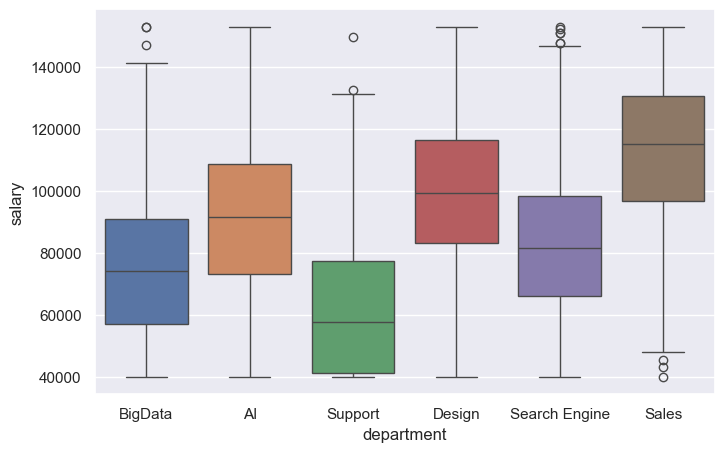

In [13]:
plt.subplots(figsize=(8,5))
sns.boxplot(data=employees,x="department", y="salary",hue="department")

plt.show()

### Observations:
Salaries for AI, Design & SEO show normal distribution.

Salaries for Sales have highest of median salaries, while Support has lowest median salaries of all departments. 

The long low whisker for Sales indicates fewer positions in Junior level than more senior positions , where most of the data points are concentrated (hence the higher position of the box) . 

Similar ,but on opposite spectrum for Support - where majority of salaries lie on lower tier with few senior roles. This is also true for Big Data roles but 

Salaries for AI & Design show a normal distribution.

### Understanding variance for each company & dept:

In [14]:
employees.groupby(['company','department'])["salary"].agg(["var","std","min","mean","max"]).round(2)

var       std        min       mean  \
company  department                                                    
Cheerper AI             7.765931e+08  27867.42   55784.90  116305.52   
         BigData        5.305604e+08  23033.90   40000.00   79836.58   
         Design         1.594434e+06   1262.71  151214.26  152107.13   
         Search Engine  5.470441e+08  23388.97   40000.00   95039.43   
         Support        4.783165e+08  21870.45   40000.00   62801.96   
Glasses  AI             5.788594e+08  24059.50   40000.00   93894.41   
         BigData        3.696646e+08  19226.66   40000.00   62635.60   
         Design         5.921518e+08  24334.17   42531.20  109201.14   
         Sales          2.860641e+08  16913.43   93173.64  126381.24   
         Search Engine  5.155831e+08  22706.45   40000.00   79142.21   
         Support        2.166335e+07   4654.39   40000.00   42321.38   
Pear     AI             5.290036e+08  23000.08   40000.00   73660.21   
         Design         5.707450e+08  23890.27   40000.00   91688.73   
         Sales          6.567219e+08  25626.59   40000.00  112010.74   
         Search Engine  2.684465e+08  16384.34   40000.00   60434.00   

                              max  
company  department                
Cheerper AI             153000.00  
         BigData        153000.00  
         Design         153000.00  
         Search Engine  153000.00  
         Support        149578.87  
Glasses  AI             153000.00  
         BigData        153000.00  
         Design         153000.00  
         Sales          153000.00  
         Search Engine  150802.10  
         Support         51780.32  
Pear     AI             145221.38  
         Design         153000.00  
         Sales          153000.00  
         Search Engine   92260.52

C:\Users\abhijeet.bhambere\AppData\Local\Temp\ipykernel_18852\4208007210.py:27: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k" (-> color=(0.1, 0.1, 0.1, 1)). The keyword argument will take precedence.
  axs[1].plot(x, p, 'k', linewidth=2, color='darkblue')
C:\Users\abhijeet.bhambere\AppData\Local\Temp\ipykernel_18852\4208007210.py:33: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k" (-> color=(0.1, 0.1, 0.1, 1)). The keyword argument will take precedence.
  axs[2].plot(x, p, 'k', linewidth=2, color='darkblue')


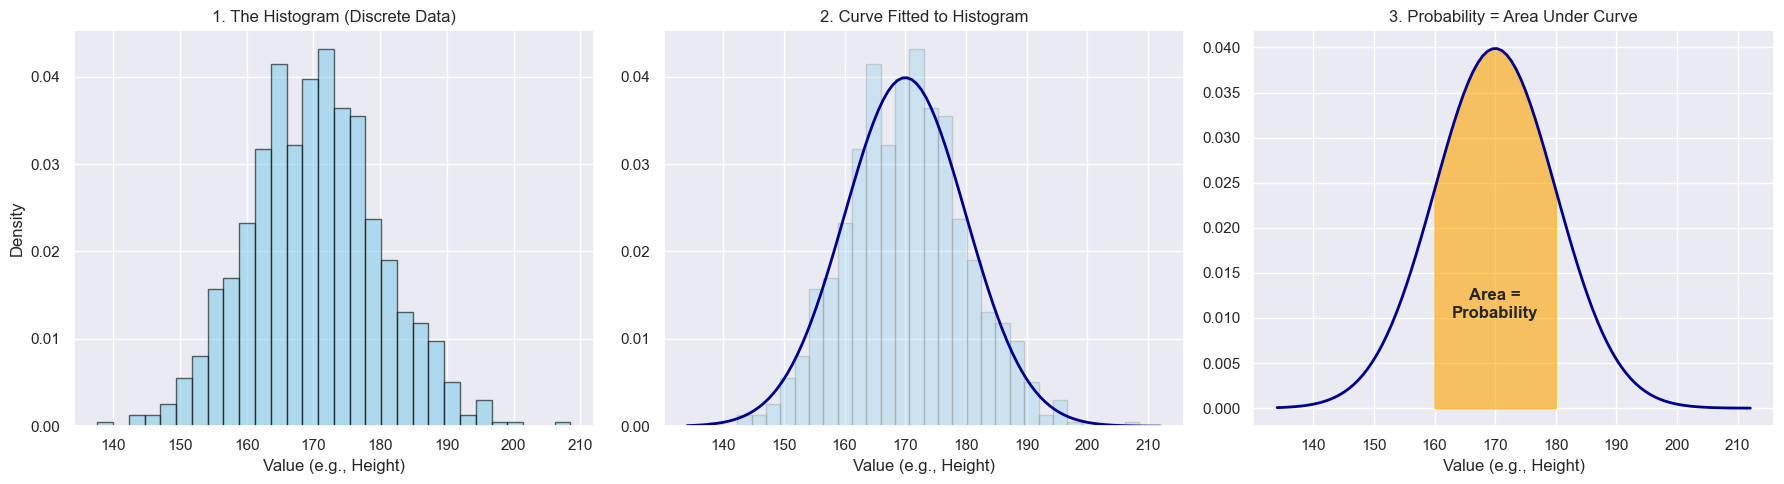

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. Generate synthetic data (e.g., heights of 1000 people)
# Mean = 170cm, Standard Deviation = 10cm
np.random.seed(42)
data = np.random.normal(loc=170, scale=10, size=1000)

# Create a figure with 3 subplots
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: The Histogram (Normalized)
# We use density=True so the total area of bars = 1
axs[0].hist(data, bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black')
axs[0].set_title('1. The Histogram (Discrete Data)')
axs[0].set_xlabel('Value (e.g., Height)')
axs[0].set_ylabel('Density')

# Plot 2: Fitting the Curve (PDF)
# Calculate the PDF for the range of x
xmin, xmax = axs[0].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, 170, 10) # Normal distribution with our mean/std

axs[1].hist(data, bins=30, density=True, alpha=0.3, color='skyblue', edgecolor='grey')
axs[1].plot(x, p, 'k', linewidth=2, color='darkblue')
axs[1].set_title('2. Curve Fitted to Histogram')
axs[1].set_xlabel('Value (e.g., Height)')

# Plot 3: Calculating Area (Probability)
# Let's find probability of being between 160 and 180
axs[2].plot(x, p, 'k', linewidth=2, color='darkblue')
axs[2].set_title('3. Probability = Area Under Curve')
axs[2].set_xlabel('Value (e.g., Height)')

# Fill the area between 160 and 180
x_fill = np.linspace(160, 180, 100)
p_fill = norm.pdf(x_fill, 170, 10)
axs[2].fill_between(x_fill, p_fill, color='orange', alpha=0.6)
axs[2].text(170, 0.01, 'Area =\nProbability', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [16]:
df = pd.read_csv("./stats_datasets/weightsheights.csv",usecols=["Height in cm","Weight in kg"])
df.info()
print("\n")
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Height in cm  25000 non-null  float64
 1   Weight in kg  25000 non-null  float64
dtypes: float64(2)
memory usage: 390.8 KB


   Height in cm  Weight in kg
0    167.089517     51.252597
1    181.648535     61.909672
2    176.272704     69.411917
3    173.270070     64.562328
4    172.180944     65.452141


array([[<Axes: title={'center': 'Height in cm'}>]], dtype=object)

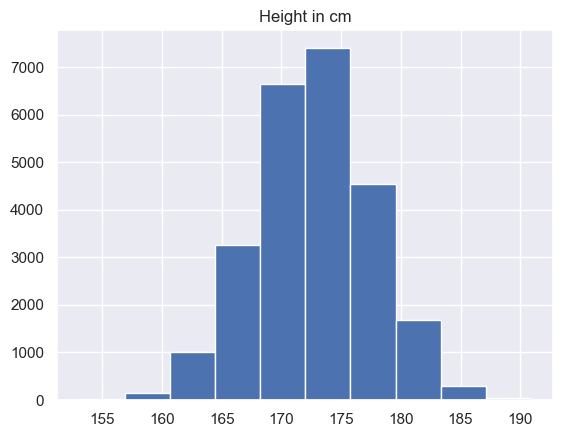

In [17]:
df.hist('Height in cm')

In [18]:
df[(df['Height in cm']>170) & (df['Height in cm']<172)]

,Height in cm,Weight in kg
11,171.763165,51.774455
13,170.475970,55.547804
19,170.513105,56.265887
24,171.775129,64.342200
25,170.709853,58.842068
...,...,...
24971,171.442795,55.784852
24977,170.814628,49.313623
24984,171.670862,57.933521
24994,170.716508,57.905807


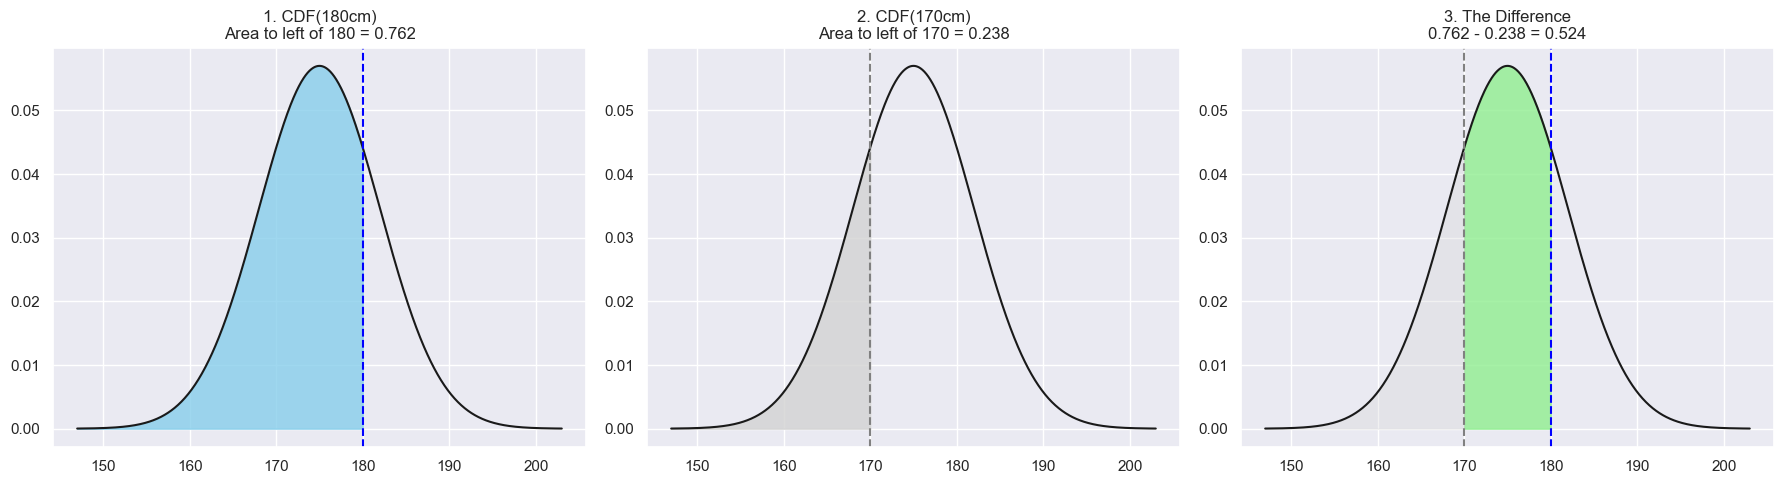

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

mean = 175
sd = 7
x = np.linspace(mean - 4*sd, mean + 4*sd, 1000)
y = norm.pdf(x, mean, sd)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: CDF of Upper Bound (180)
ax1.plot(x, y, 'k')
fill_x = np.linspace(mean - 4*sd, 180, 1000)
fill_y = norm.pdf(fill_x, mean, sd)
ax1.fill_between(fill_x, fill_y, color='skyblue', alpha=0.8)
ax1.set_title(f'1. CDF(180cm)\nArea to left of 180 = 0.762')
ax1.axvline(180, color='blue', linestyle='--')

# Plot 2: CDF of Lower Bound (170)
ax2.plot(x, y, 'k')
fill_x = np.linspace(mean - 4*sd, 170, 1000)
fill_y = norm.pdf(fill_x, mean, sd)
ax2.fill_between(fill_x, fill_y, color='lightgrey', alpha=0.8)
ax2.set_title(f'2. CDF(170cm)\nArea to left of 170 = 0.238')
ax2.axvline(170, color='gray', linestyle='--')

# Plot 3: The Result (Difference)
ax3.plot(x, y, 'k')
# Fill the middle
mid_x = np.linspace(170, 180, 1000)
mid_y = norm.pdf(mid_x, mean, sd)
ax3.fill_between(mid_x, mid_y, color='lightgreen', alpha=0.8)
# Show the "removed" part faintly
ax3.fill_between(fill_x, fill_y, color='lightgrey', alpha=0.3)
ax3.set_title(f'3. The Difference\n0.762 - 0.238 = 0.524')
ax3.axvline(180, color='blue', linestyle='--')
ax3.axvline(170, color='gray', linestyle='--')

plt.tight_layout()
plt.show()

In [20]:
height_std = int(round(df["Height in cm"].std(),0))
height_avg = int(round(df["Height in cm"].mean(),0))
print(f"Average height is: {height_avg}")
print(f"Std deviation in height is: {height_std}")

Average height is: 173
Std deviation in height is: 5


<Axes: >

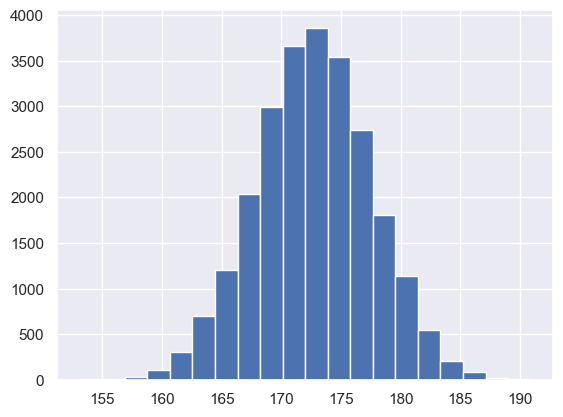

In [21]:
df["Height in cm"].hist(bins=20)

In [22]:
from scipy.stats import binom,norm
n= 5 #no. of trials for a coin toss
p = 0.5 #probability of success (50% each for H/ T)

In [23]:
# Getting exactly 3 heads from the 5 trials
binom.pmf(k=3,n=n, p=p)

np.float64(0.3124999999999998)

So 31.2% chance to get exactly 3 heads out of 5 trials

In [24]:
# PDF for a continuous random variable
# Data has Normal distribution with mean=170cm & Std=10cm

mu = 170
std = 10
heights = np.array([150,150,170,180,190])

norm.pdf(x=heights, loc=mu, scale=std)


array([0.0053991 , 0.0053991 , 0.03989423, 0.02419707, 0.0053991 ])